# PARKINSON'S DISEASE DETECTION - PAPER + CUSTOM DROPOUT
## Colab notebook with Optimized-style layout and paper-like model settings

**Dataset:** https://www.kaggle.com/datasets/kmader/parkinsons-drawings  
**Models:** VGG19, InceptionV3, ResNet50V2, DenseNet169  
**Goal:** reproduce the paper as closely as possible while adding one custom layer.  
**Custom idea:** add one `Dropout` layer after the Dense classification layer to reduce overfitting on the small 102-image dataset.  
**Output style:** similar to `Parkinson_Demo_Optimized.ipynb`, including test accuracy, test AUC, threshold and best epoch.

---
## STEP 1: SETUP & MOUNT GOOGLE DRIVE

In [1]:
import os
import random
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.applications import DenseNet169, InceptionV3, ResNet50V2, VGG19
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.metrics import AUC
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('Libraries imported!')
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

Libraries imported!
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('\nGoogle Drive mounted!')
except Exception as e:
    print('Google Drive mount skipped:', e)

Mounted at /content/drive

Google Drive mounted!


In [3]:
class HistoryContainer:
    def __init__(self, history):
        self.history = history


def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['auc'], label='Train AUC', linewidth=2)
    axes[1].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
    axes[1].set_title(f'{model_name} - AUC', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('AUC', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)

    axes[2].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[2].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[2].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Loss', fontsize=12)
    axes[2].legend(fontsize=11)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plot_file = os.path.join(PLOT_PATH, f'{model_name}_training_history.png')
    plt.savefig(plot_file, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Plot saved: {plot_file}\n')


def safe_roc_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return float('nan')


def find_best_threshold(model, val_generator):
    val_generator.reset()
    y_prob = model.predict(val_generator, verbose=0)
    y_true = val_generator.classes
    parkinson_idx = val_generator.class_indices['parkinson']
    y_score = y_prob[:, parkinson_idx]

    threshold_grid = np.linspace(0.25, 0.75, 51)
    best_threshold = 0.5
    best_acc = -1.0
    best_balanced_acc = -1.0
    best_f1 = -1.0

    for threshold in threshold_grid:
        y_pred = (y_score >= threshold).astype(int)
        acc = accuracy_score(y_true, y_pred)
        balanced_acc = balanced_accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if (acc > best_acc) or (acc == best_acc and balanced_acc > best_balanced_acc) or (acc == best_acc and balanced_acc == best_balanced_acc and f1 > best_f1) or (acc == best_acc and balanced_acc == best_balanced_acc and f1 == best_f1 and abs(threshold - 0.5) < abs(best_threshold - 0.5)):
            best_threshold = float(threshold)
            best_acc = float(acc)
            best_balanced_acc = float(balanced_acc)
            best_f1 = float(f1)

    print(f'Best validation threshold: {best_threshold:.2f}')
    print(f'Validation accuracy at best threshold: {best_acc:.4f}')
    print(f'Validation balanced accuracy at best threshold: {best_balanced_acc:.4f}')
    print(f'Validation F1 at best threshold: {best_f1:.4f}')

    return best_threshold


def evaluate_model(model, generator, model_name, threshold=0.5):
    generator.reset()

    y_prob = model.predict(generator, verbose=0)
    y_true = generator.classes
    parkinson_idx = generator.class_indices['parkinson']
    y_score = y_prob[:, parkinson_idx]
    y_pred = (y_score >= threshold).astype(int)

    eval_values = model.evaluate(generator, verbose=0)
    test_loss = eval_values[0]
    test_auc = safe_roc_auc(y_true, y_score)
    test_acc = accuracy_score(y_true, y_pred)

    target_names = [label for label, _ in sorted(generator.class_indices.items(), key=lambda item: item[1])]

    print(f'\nCLASSIFICATION REPORT - {model_name}')
    print('=' * 60)
    print(f'Threshold used: {threshold:.2f}')
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, cbar_kws={'label': 'Count'}, annot_kws={'size': 14, 'weight': 'bold'})
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    cm_file = os.path.join(PLOT_PATH, f'{model_name}_confusion_matrix.png')
    plt.savefig(cm_file, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Confusion Matrix saved: {cm_file}')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {test_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'{model_name} - ROC', fontsize=14, fontweight='bold')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    roc_file = os.path.join(PLOT_PATH, f'{model_name}_roc.png')
    plt.savefig(roc_file, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'ROC plot saved: {roc_file}')

    return {
        'test_acc': float(test_acc),
        'test_loss': float(test_loss),
        'test_auc': float(test_auc),
        'threshold': float(threshold),
        'confusion_matrix': cm,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_score': y_score,
    }


print('Plotting and evaluation functions defined!')

Plotting and evaluation functions defined!


---
## STEP 2: PREPARE DATA

In [4]:
DATASET_PATH = '/content/drive/MyDrive/Parkinsons/drawings/spiral'
SAVE_PATH = '/content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout'
PLOT_PATH = os.path.join(SAVE_PATH, 'plots')
MODEL_PATH = os.path.join(SAVE_PATH, 'models')
SPLIT_PATH = os.path.join(SAVE_PATH, 'splits')
RANDOM_SEED = 42
TEST_SIZE = 20
VAL_SIZE_FROM_TRAIN = 0.2
EPOCHS = 50
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.30

print('Configuration:')
print('  Dataset path:', DATASET_PATH)
print('  Save path:', SAVE_PATH)
print('  Plot path:', PLOT_PATH)
print('  Model path:', MODEL_PATH)
print('  Test size:', TEST_SIZE)
print('  Validation size from train:', VAL_SIZE_FROM_TRAIN)
print('  Epochs:', EPOCHS)
print('  Custom layer: Dropout')
print('  Dropout rate:', DROPOUT_RATE)

Configuration:
  Dataset path: /content/drive/MyDrive/Parkinsons/drawings/spiral
  Save path: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout
  Plot path: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots
  Model path: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models
  Test size: 20
  Validation size from train: 0.2
  Epochs: 50
  Custom layer: Dropout
  Dropout rate: 0.3


In [5]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(PLOT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(SPLIT_PATH, exist_ok=True)

print('Seed fixed and directories ready!')

Seed fixed and directories ready!


In [6]:
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp')

def collect_dataset(dataset_root):
    rows = []
    for split_name in ['training', 'testing', '']:
        split_dir = os.path.join(dataset_root, split_name) if split_name else dataset_root
        for label in ['healthy', 'parkinson']:
            label_dir = os.path.join(split_dir, label)
            if not os.path.isdir(label_dir):
                continue
            for filename in sorted(os.listdir(label_dir)):
                if not filename.lower().endswith(IMAGE_EXTENSIONS):
                    continue
                file_path = os.path.join(label_dir, filename)
                if os.path.isfile(file_path):
                    rows.append({'filepath': file_path, 'label': label, 'source_split': split_name or 'root'})

    df = pd.DataFrame(rows).drop_duplicates(subset=['filepath']).reset_index(drop=True)
    if df.empty:
        raise FileNotFoundError(f'No images found in: {dataset_root}')
    return df


all_df = collect_dataset(DATASET_PATH)

print('Full dataset collected:', len(all_df))
print(all_df['label'].value_counts())
print('Source split counts:')
print(all_df.groupby(['source_split', 'label']).size())

if len(all_df) != 102:
    print('Warning: paper dataset has 102 spiral images, but collected:', len(all_df))

Full dataset collected: 102
label
healthy      51
parkinson    51
Name: count, dtype: int64
Source split counts:
source_split  label    
testing       healthy      15
              parkinson    15
training      healthy      36
              parkinson    36
dtype: int64


In [7]:
train_val_df, test_df = train_test_split(
    all_df,
    test_size=TEST_SIZE,
    stratify=all_df['label'],
    random_state=RANDOM_SEED
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_SIZE_FROM_TRAIN,
    stratify=train_val_df['label'],
    random_state=RANDOM_SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Data split complete!')
print('  Train samples:', len(train_df))
print('  Validation samples:', len(val_df))
print('  Test samples:', len(test_df))

print('\nTrain class balance:')
print(train_df['label'].value_counts())
print('\nValidation class balance:')
print(val_df['label'].value_counts())
print('\nTest class balance:')
print(test_df['label'].value_counts())

Data split complete!
  Train samples: 65
  Validation samples: 17
  Test samples: 20

Train class balance:
label
parkinson    33
healthy      32
Name: count, dtype: int64

Validation class balance:
label
healthy      9
parkinson    8
Name: count, dtype: int64

Test class balance:
label
parkinson    10
healthy      10
Name: count, dtype: int64


In [8]:
train_df.to_csv(os.path.join(SPLIT_PATH, 'train_split.csv'), index=False)
val_df.to_csv(os.path.join(SPLIT_PATH, 'val_split.csv'), index=False)
test_df.to_csv(os.path.join(SPLIT_PATH, 'test_split.csv'), index=False)

print('Split CSV files saved to:', SPLIT_PATH)

Split CSV files saved to: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/splits


---
## STEP 3: BUILD MODELS

In [9]:
MODEL_CONFIGS = {
    'VGG19': {
        'builder': VGG19,
        'img_size': 100,
        'batch_size': 16,
        'dense_units': 64,
        'paper_accuracy': 0.72,
    },
    'InceptionV3': {
        'builder': InceptionV3,
        'img_size': 100,
        'batch_size': 32,
        'dense_units': 128,
        'paper_accuracy': 0.89,
    },
    'ResNet50V2': {
        'builder': ResNet50V2,
        'img_size': 224,
        'batch_size': 32,
        'dense_units': 128,
        'paper_accuracy': 0.80,
    },
    'DenseNet169': {
        'builder': DenseNet169,
        'img_size': 224,
        'batch_size': 16,
        'dense_units': 128,
        'paper_accuracy': 0.85,
    },
}

print('Model configs defined!')
for name, cfg in MODEL_CONFIGS.items():
    print(f"  {name}: img={cfg['img_size']}, batch={cfg['batch_size']}, dense={cfg['dense_units']}, dropout={DROPOUT_RATE}, paper_acc={cfg['paper_accuracy'] * 100:.0f}%")

Model configs defined!
  VGG19: img=100, batch=16, dense=64, dropout=0.3, paper_acc=72%
  InceptionV3: img=100, batch=32, dense=128, dropout=0.3, paper_acc=89%
  ResNet50V2: img=224, batch=32, dense=128, dropout=0.3, paper_acc=80%
  DenseNet169: img=224, batch=16, dense=128, dropout=0.3, paper_acc=85%


In [10]:
def create_generators(config):
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255.0,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    eval_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

    train_generator = train_datagen.flow_from_dataframe(
        train_df,
        x_col='filepath',
        y_col='label',
        target_size=(config['img_size'], config['img_size']),
        batch_size=config['batch_size'],
        class_mode='categorical',
        shuffle=True,
        seed=RANDOM_SEED
    )

    val_generator = eval_datagen.flow_from_dataframe(
        val_df,
        x_col='filepath',
        y_col='label',
        target_size=(config['img_size'], config['img_size']),
        batch_size=config['batch_size'],
        class_mode='categorical',
        shuffle=False
    )

    test_generator = eval_datagen.flow_from_dataframe(
        test_df,
        x_col='filepath',
        y_col='label',
        target_size=(config['img_size'], config['img_size']),
        batch_size=config['batch_size'],
        class_mode='categorical',
        shuffle=False
    )

    return train_generator, val_generator, test_generator


def create_model(config, model_name):
    base_model = config['builder'](
        weights='imagenet',
        include_top=False,
        pooling='avg',
        input_shape=(config['img_size'], config['img_size'], 3)
    )

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = Dense(config['dense_units'], activation='relu', name='paper_dense_layer')(x)
    x = Dropout(DROPOUT_RATE, name='custom_dropout_layer')(x)
    outputs = Dense(2, activation='softmax', name='output_softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs, name=f'{model_name}_paper_custom_dropout')
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )

    print(f'\n{model_name} created!')
    print(f"  Total params: {model.count_params():,}")
    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f"  Trainable params: {trainable_params:,}")
    print('  Added custom layer: Dropout')

    return model


def get_callbacks(model_name):
    checkpoint_file = os.path.join(MODEL_PATH, f'{model_name}_best_val_accuracy.keras')
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_file,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    return [checkpoint], checkpoint_file


def train_model(model_name):
    tf.keras.backend.clear_session()
    gc.collect()

    config = MODEL_CONFIGS[model_name]
    train_generator, val_generator, test_generator = create_generators(config)

    print(f'  Train batches: {len(train_generator)}')
    print(f'  Val batches: {len(val_generator)}')
    print(f'  Test batches: {len(test_generator)}')

    model = create_model(config, model_name)

    print('\nTraining paper-like model with custom Dropout layer')
    callbacks, checkpoint_file = get_callbacks(model_name)
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    if os.path.exists(checkpoint_file):
        model = tf.keras.models.load_model(checkpoint_file)
        print(f'Loaded best validation checkpoint: {checkpoint_file}')

    plot_training_history(history, model_name)

    best_threshold = find_best_threshold(model, val_generator)
    eval_results = evaluate_model(model, test_generator, model_name, threshold=best_threshold)

    final_model_file = os.path.join(MODEL_PATH, f'{model_name}_paper_custom_dropout.keras')
    model.save(final_model_file)
    print(f'Saved final model: {final_model_file}')

    return {
        'history': HistoryContainer(history.history),
        'test_acc': eval_results['test_acc'],
        'test_loss': eval_results['test_loss'],
        'test_auc': eval_results['test_auc'],
        'threshold': eval_results['threshold'],
        'model': model,
        'eval': eval_results,
        'config': config,
        'checkpoint_file': checkpoint_file,
        'final_model_file': final_model_file,
    }


print('Model helper functions defined!')

Model helper functions defined!


---
## STEP 4: TRAIN MODELS

In [11]:
results = {}

print('Starting training process...\n')
print('=' * 60)

Starting training process...



### 4.1. VGG19


TRAINING MODEL 1/4: VGG19
Found 65 validated image filenames belonging to 2 classes.
Found 17 validated image filenames belonging to 2 classes.
Found 20 validated image filenames belonging to 2 classes.
  Train batches: 5
  Val batches: 2
  Test batches: 2
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

VGG19 created!
  Total params: 20,057,346
  Trainable params: 32,962
  Added custom layer: Dropout

Training paper-like model with custom Dropout layer
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5355 - auc: 0.4982 - loss: 0.7312
Epoch 1: val_accuracy improved from None to 0.64706, saving model to /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/VGG19_best_val_accuracy.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/VGG19_best_val_accuracy.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - accuracy: 0.5692 - auc: 0.5408 - loss: 0.7099 - val_accuracy: 0.6471 - val_auc: 0.5934 - val_loss: 0.684

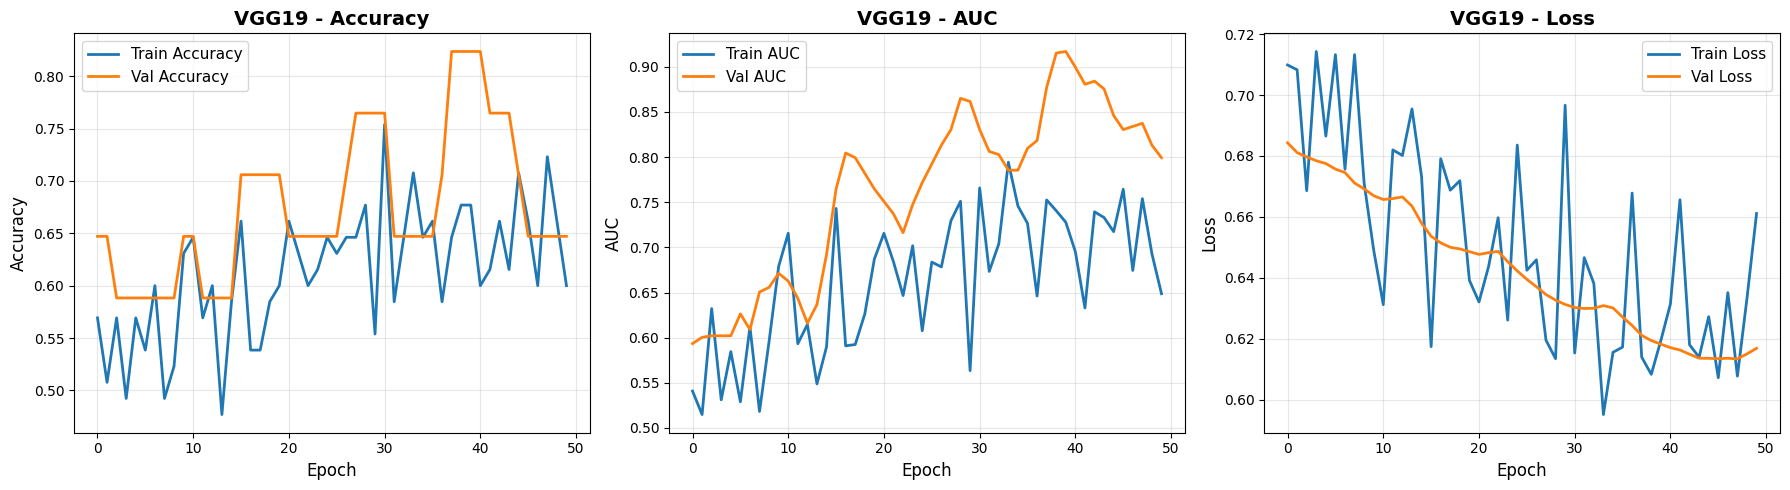

Plot saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/VGG19_training_history.png

Best validation threshold: 0.48
Validation accuracy at best threshold: 0.8824
Validation balanced accuracy at best threshold: 0.8750
Validation F1 at best threshold: 0.8571

CLASSIFICATION REPORT - VGG19
Threshold used: 0.48
              precision    recall  f1-score   support

     healthy     1.0000    0.9000    0.9474        10
   parkinson     0.9091    1.0000    0.9524        10

    accuracy                         0.9500        20
   macro avg     0.9545    0.9500    0.9499        20
weighted avg     0.9545    0.9500    0.9499        20



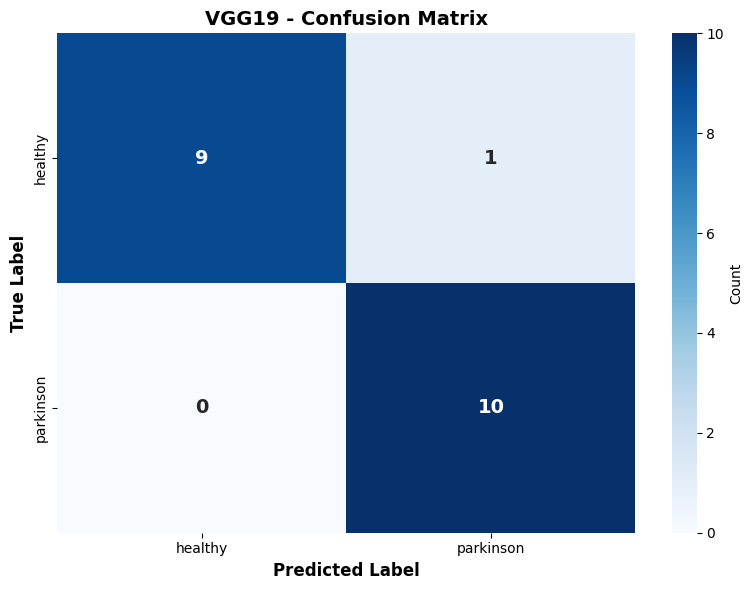

Confusion Matrix saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/VGG19_confusion_matrix.png


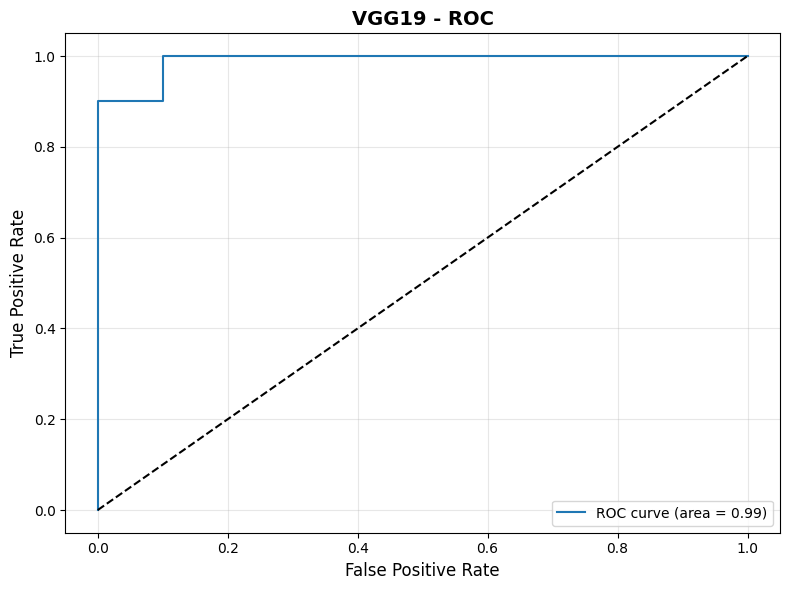

ROC plot saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/VGG19_roc.png
Saved final model: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/VGG19_paper_custom_dropout.keras

VGG19 TRAINING COMPLETE!
  Test Accuracy: 95.00%
  Test AUC: 0.9900
  Threshold: 0.48
  Test Loss: 0.5981


In [12]:
print('\n' + '=' * 60)
print('TRAINING MODEL 1/4: VGG19')
print('=' * 60)

results['VGG19'] = train_model('VGG19')

print(f"\n{'=' * 60}")
print('VGG19 TRAINING COMPLETE!')
print(f"  Test Accuracy: {results['VGG19']['test_acc'] * 100:.2f}%")
print(f"  Test AUC: {results['VGG19']['test_auc']:.4f}")
print(f"  Threshold: {results['VGG19']['threshold']:.2f}")
print(f"  Test Loss: {results['VGG19']['test_loss']:.4f}")
print(f"{'=' * 60}")

### 4.2. InceptionV3


TRAINING MODEL 2/4: InceptionV3
Found 65 validated image filenames belonging to 2 classes.
Found 17 validated image filenames belonging to 2 classes.
Found 20 validated image filenames belonging to 2 classes.
  Train batches: 3
  Val batches: 1
  Test batches: 1
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

InceptionV3 created!
  Total params: 22,065,314
  Trainable params: 262,530
  Added custom layer: Dropout

Training paper-like model with custom Dropout layer
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5183 - auc: 0.5414 - loss: 1.1967  
Epoch 1: val_accuracy improved from None to 0.52941, saving model to /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/InceptionV3_best_val_accuracy.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/InceptionV3_best_val_accuracy.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 9s/step - accuracy: 0.4769 - auc: 0.5049 - loss: 1.2248 - val_accuracy: 0.5294 - val_au

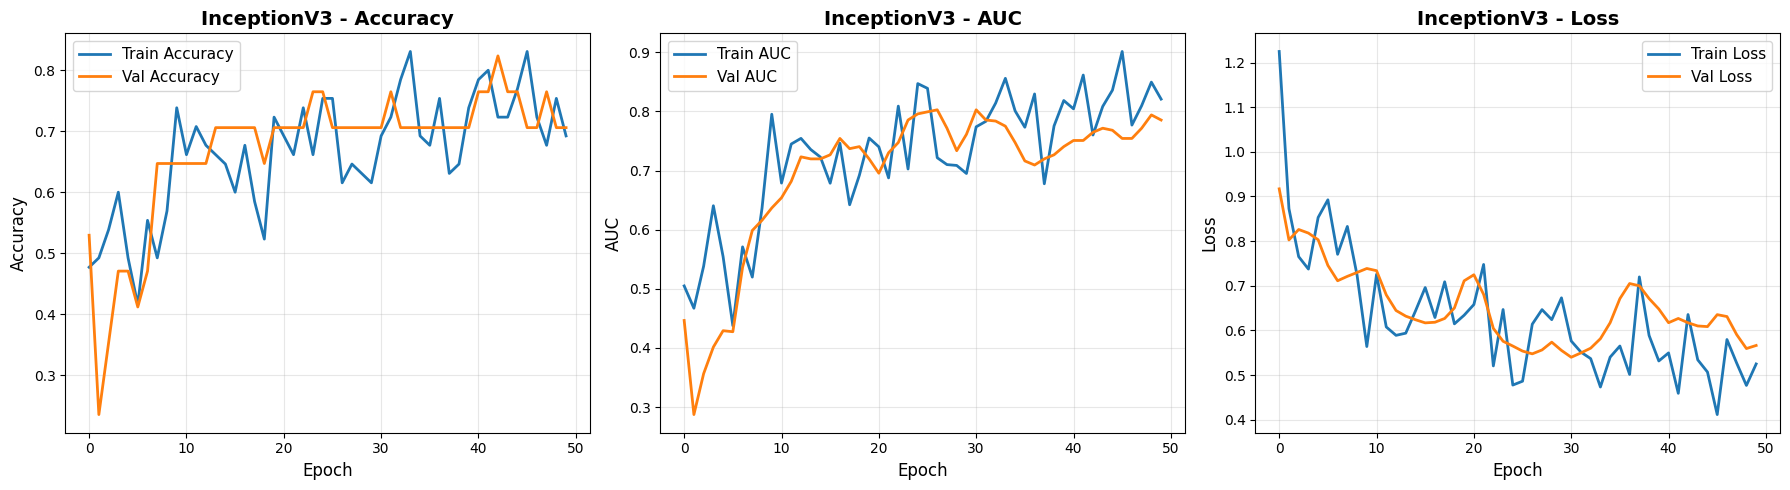

Plot saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/InceptionV3_training_history.png

Best validation threshold: 0.50
Validation accuracy at best threshold: 0.8235
Validation balanced accuracy at best threshold: 0.8125
Validation F1 at best threshold: 0.7692

CLASSIFICATION REPORT - InceptionV3
Threshold used: 0.50
              precision    recall  f1-score   support

     healthy     0.7143    1.0000    0.8333        10
   parkinson     1.0000    0.6000    0.7500        10

    accuracy                         0.8000        20
   macro avg     0.8571    0.8000    0.7917        20
weighted avg     0.8571    0.8000    0.7917        20



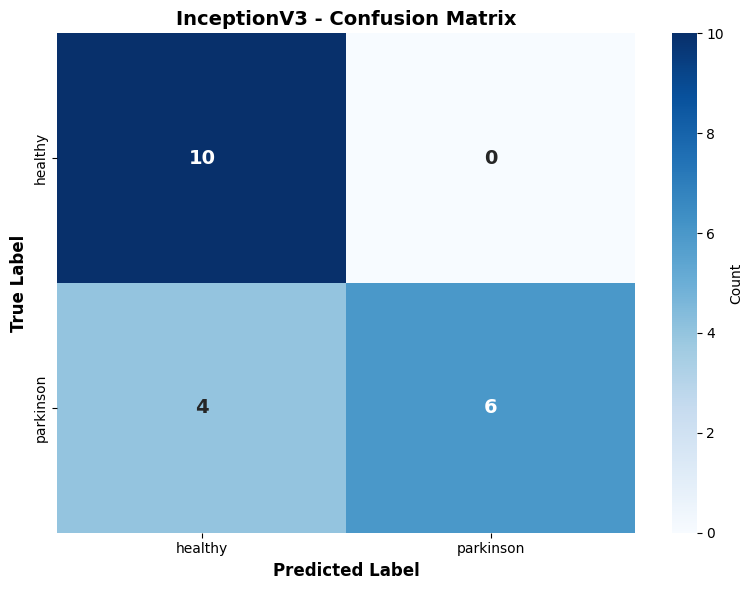

Confusion Matrix saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/InceptionV3_confusion_matrix.png


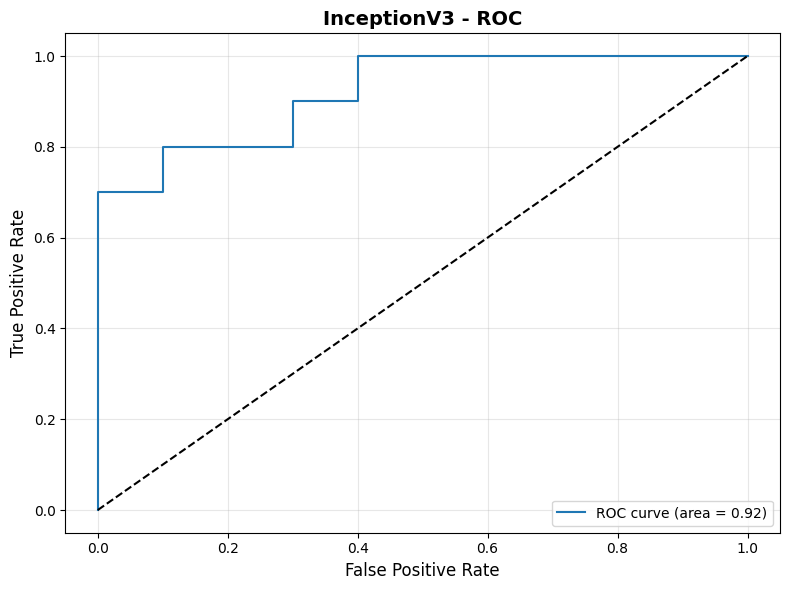

ROC plot saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/InceptionV3_roc.png
Saved final model: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/InceptionV3_paper_custom_dropout.keras

InceptionV3 TRAINING COMPLETE!
  Test Accuracy: 80.00%
  Test AUC: 0.9200
  Threshold: 0.50
  Test Loss: 0.4105


In [13]:
print('\n' + '=' * 60)
print('TRAINING MODEL 2/4: InceptionV3')
print('=' * 60)

results['InceptionV3'] = train_model('InceptionV3')

print(f"\n{'=' * 60}")
print('InceptionV3 TRAINING COMPLETE!')
print(f"  Test Accuracy: {results['InceptionV3']['test_acc'] * 100:.2f}%")
print(f"  Test AUC: {results['InceptionV3']['test_auc']:.4f}")
print(f"  Threshold: {results['InceptionV3']['threshold']:.2f}")
print(f"  Test Loss: {results['InceptionV3']['test_loss']:.4f}")
print(f"{'=' * 60}")

### 4.3. ResNet50V2


TRAINING MODEL 3/4: ResNet50V2
Found 65 validated image filenames belonging to 2 classes.
Found 17 validated image filenames belonging to 2 classes.
Found 20 validated image filenames belonging to 2 classes.
  Train batches: 3
  Val batches: 1
  Test batches: 1
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

ResNet50V2 created!
  Total params: 23,827,330
  Trainable params: 262,530
  Added custom layer: Dropout

Training paper-like model with custom Dropout layer
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4664 - auc: 0.4825 - loss: 0.8327   
Epoch 1: val_accuracy improved from None to 0.76471, saving model to /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/ResNet50V2_best_val_accuracy.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/ResNet50V2_best_val_accuracy.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 7s/step - accuracy: 0.4462 - auc: 0.4690 - loss: 0.8346 - val_accuracy: 0.7647 - val_auc: 

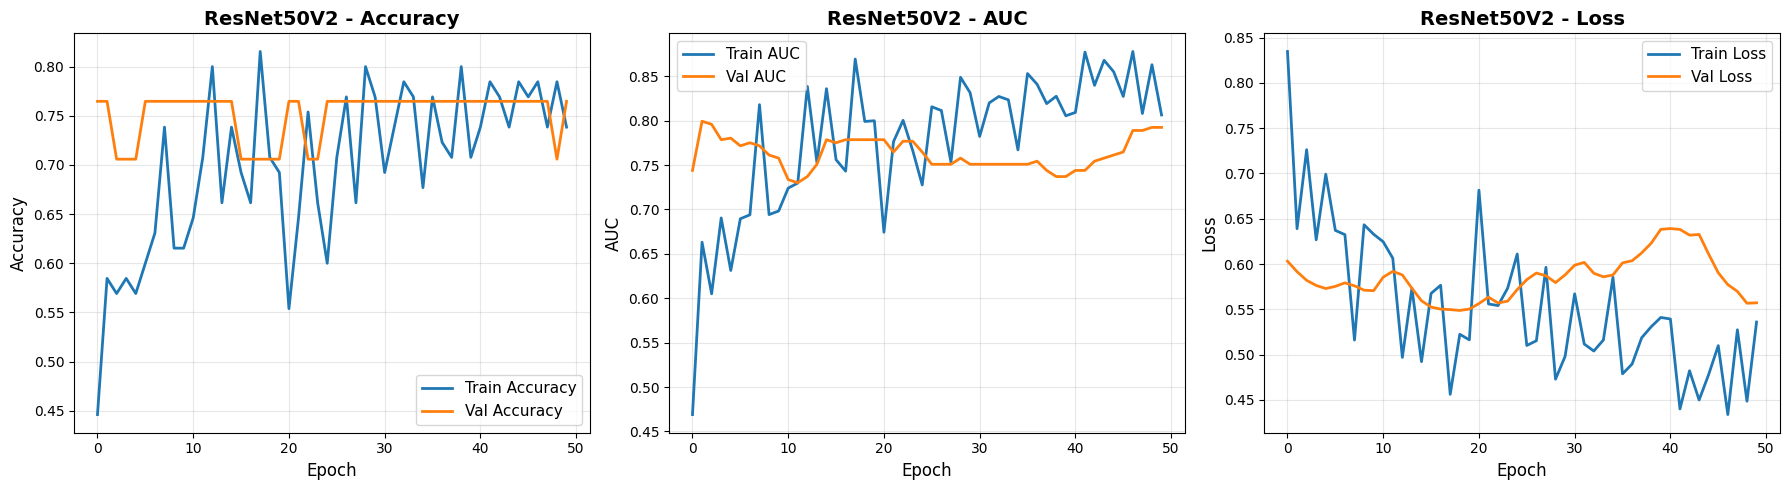

Plot saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/ResNet50V2_training_history.png



Best validation threshold: 0.46
Validation accuracy at best threshold: 0.8235
Validation balanced accuracy at best threshold: 0.8264
Validation F1 at best threshold: 0.8235



CLASSIFICATION REPORT - ResNet50V2
Threshold used: 0.46
              precision    recall  f1-score   support

     healthy     0.6667    0.6000    0.6316        10
   parkinson     0.6364    0.7000    0.6667        10

    accuracy                         0.6500        20
   macro avg     0.6515    0.6500    0.6491        20
weighted avg     0.6515    0.6500    0.6491        20



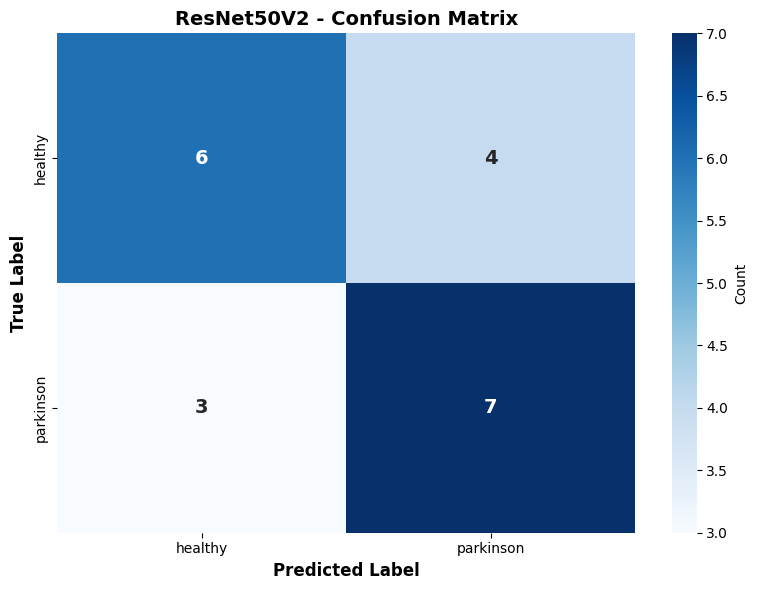

Confusion Matrix saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/ResNet50V2_confusion_matrix.png


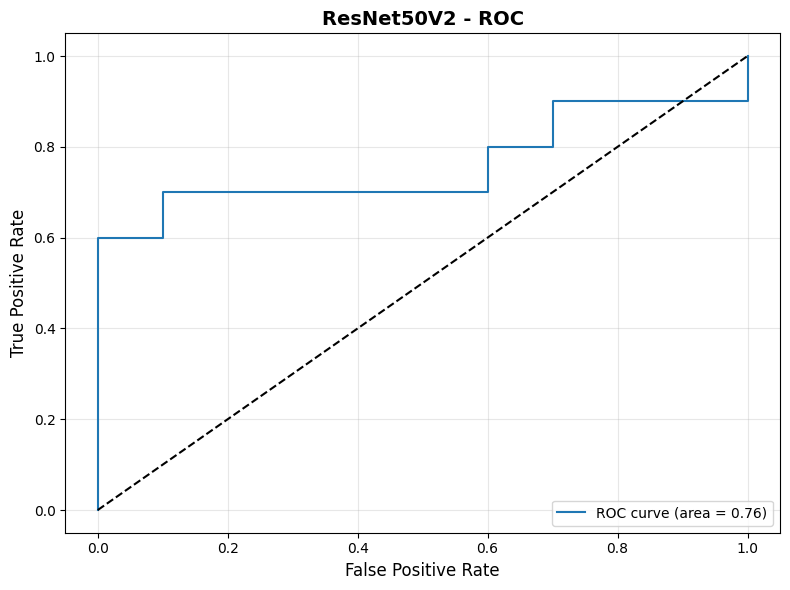

ROC plot saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/ResNet50V2_roc.png
Saved final model: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/ResNet50V2_paper_custom_dropout.keras

ResNet50V2 TRAINING COMPLETE!
  Test Accuracy: 65.00%
  Test AUC: 0.7600
  Threshold: 0.46
  Test Loss: 0.6072


In [14]:
print('\n' + '=' * 60)
print('TRAINING MODEL 3/4: ResNet50V2')
print('=' * 60)

results['ResNet50V2'] = train_model('ResNet50V2')

print(f"\n{'=' * 60}")
print('ResNet50V2 TRAINING COMPLETE!')
print(f"  Test Accuracy: {results['ResNet50V2']['test_acc'] * 100:.2f}%")
print(f"  Test AUC: {results['ResNet50V2']['test_auc']:.4f}")
print(f"  Threshold: {results['ResNet50V2']['threshold']:.2f}")
print(f"  Test Loss: {results['ResNet50V2']['test_loss']:.4f}")
print(f"{'=' * 60}")

### 4.4. DenseNet169


TRAINING MODEL 4/4: DenseNet169
Found 65 validated image filenames belonging to 2 classes.
Found 17 validated image filenames belonging to 2 classes.
Found 20 validated image filenames belonging to 2 classes.
  Train batches: 5
  Val batches: 2
  Test batches: 2
51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

DenseNet169 created!
  Total params: 12,856,258
  Trainable params: 213,378
  Added custom layer: Dropout

Training paper-like model with custom Dropout layer
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5194 - auc: 0.4253 - loss: 0.8693
Epoch 1: val_accuracy improved from None to 0.35294, saving model to /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/DenseNet169_best_val_accuracy.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/DenseNet169_best_val_accuracy.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 97s 14s/step - accuracy: 0.4615 - auc: 0.4142 - loss: 0.8747 - val_accuracy: 0.3529 - val_auc

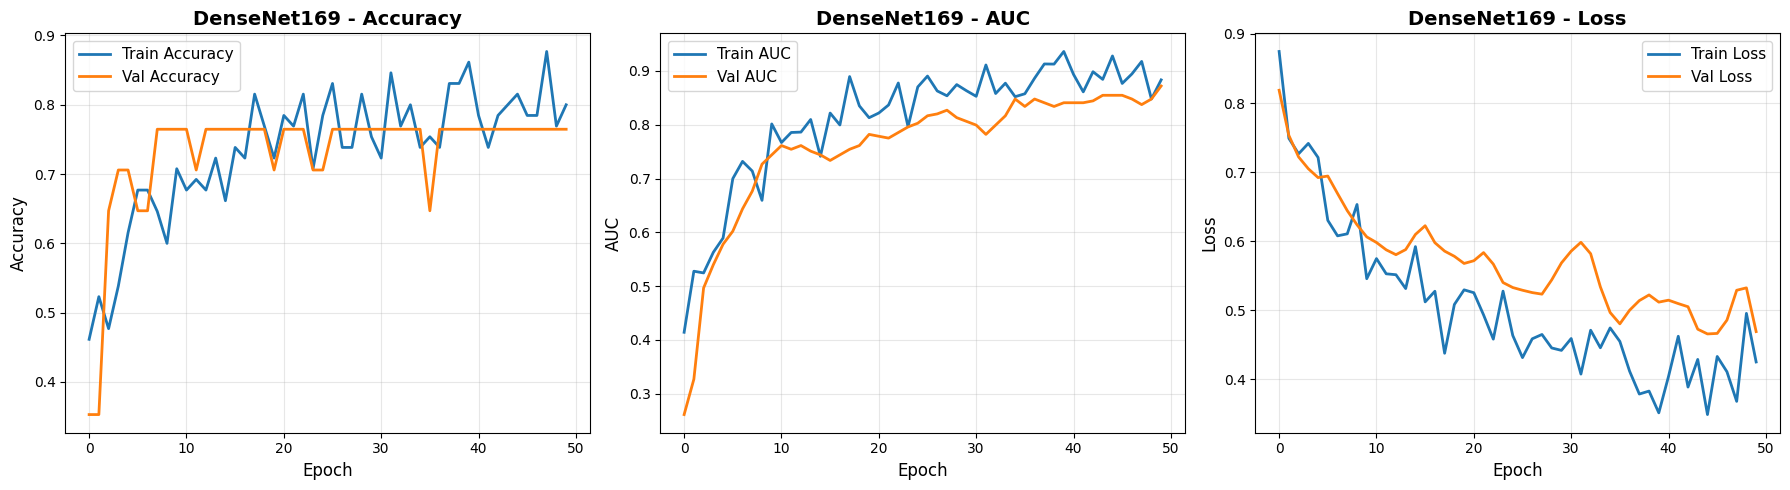

Plot saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/DenseNet169_training_history.png

Best validation threshold: 0.50
Validation accuracy at best threshold: 0.7647
Validation balanced accuracy at best threshold: 0.7500
Validation F1 at best threshold: 0.6667

CLASSIFICATION REPORT - DenseNet169
Threshold used: 0.50
              precision    recall  f1-score   support

     healthy     0.7143    1.0000    0.8333        10
   parkinson     1.0000    0.6000    0.7500        10

    accuracy                         0.8000        20
   macro avg     0.8571    0.8000    0.7917        20
weighted avg     0.8571    0.8000    0.7917        20



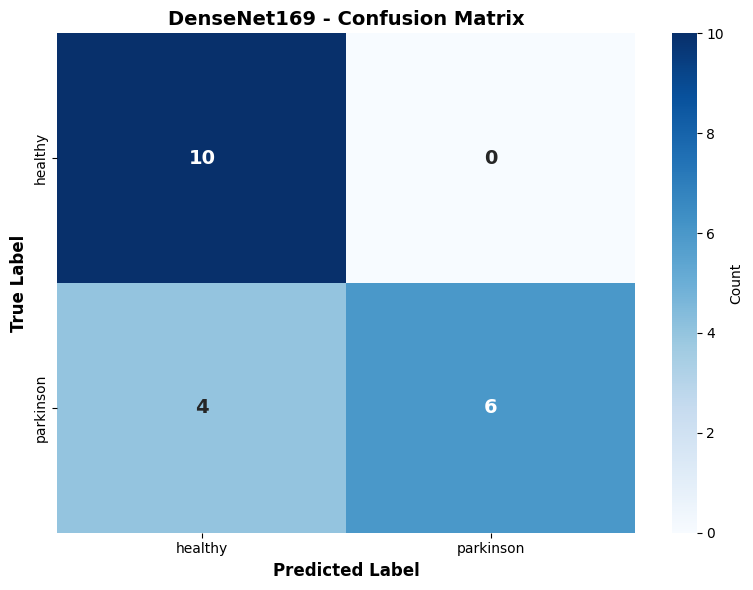

Confusion Matrix saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/DenseNet169_confusion_matrix.png


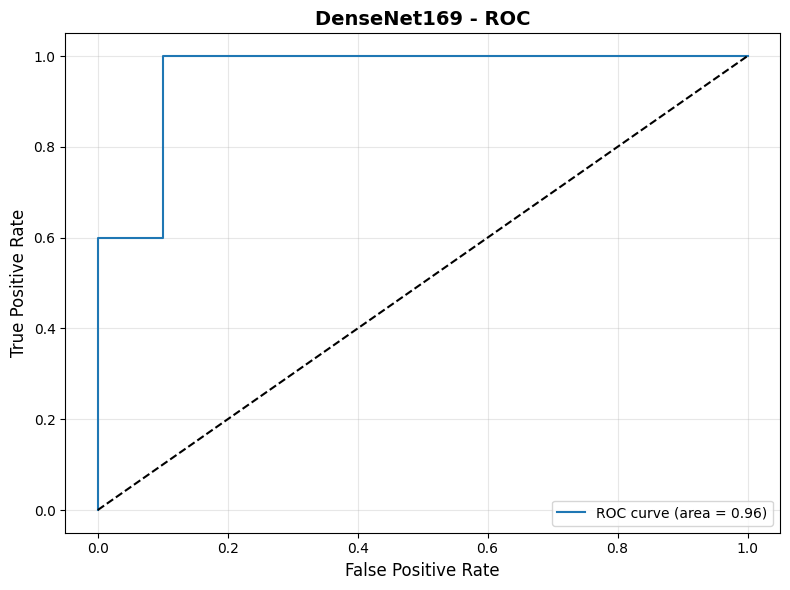

ROC plot saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/DenseNet169_roc.png
Saved final model: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/DenseNet169_paper_custom_dropout.keras

DenseNet169 TRAINING COMPLETE!
  Test Accuracy: 80.00%
  Test AUC: 0.9600
  Threshold: 0.50
  Test Loss: 0.4914


In [15]:
print('\n' + '=' * 60)
print('TRAINING MODEL 4/4: DenseNet169')
print('=' * 60)

results['DenseNet169'] = train_model('DenseNet169')

print(f"\n{'=' * 60}")
print('DenseNet169 TRAINING COMPLETE!')
print(f"  Test Accuracy: {results['DenseNet169']['test_acc'] * 100:.2f}%")
print(f"  Test AUC: {results['DenseNet169']['test_auc']:.4f}")
print(f"  Threshold: {results['DenseNet169']['threshold']:.2f}")
print(f"  Test Loss: {results['DenseNet169']['test_loss']:.4f}")
print(f"{'=' * 60}")

---
## STEP 5: VISUALIZE RESULTS

In [16]:
print('\n' + '=' * 70)
print('TRAINING RESULTS SUMMARY')
print('=' * 70)
print(f"{'Model':<15} {'Paper Acc':<12} {'Test Accuracy':<15} {'Test AUC':<12} {'Threshold':<10} {'Best Epoch':<10}")
print('-' * 95)

summary_rows = []
for model_name, data in results.items():
    best_epoch = int(np.argmax(data['history'].history['val_accuracy']) + 1)
    paper_acc = data['config']['paper_accuracy']
    test_acc = data['test_acc']
    test_auc = data['test_auc']
    threshold = data['threshold']
    print(f"{model_name:<15} {paper_acc * 100:>6.2f}%      {test_acc * 100:>6.2f}%         {test_auc:<12.4f} {threshold:<10.2f} {best_epoch:<10}")
    summary_rows.append({
        'model': model_name,
        'paper_accuracy': paper_acc,
        'notebook_test_accuracy': test_acc,
        'difference': test_acc - paper_acc,
        'notebook_test_auc': test_auc,
        'threshold': threshold,
        'best_epoch': best_epoch,
        'test_samples': len(test_df),
        'img_size': data['config']['img_size'],
        'batch_size': data['config']['batch_size'],
        'dense_units': data['config']['dense_units'],
        'dropout_rate': DROPOUT_RATE,
    })

summary_df = pd.DataFrame(summary_rows)
summary_file = os.path.join(SAVE_PATH, 'paper_custom_dropout_results_summary.csv')
summary_df.to_csv(summary_file, index=False)

best_model_name = max(results, key=lambda x: results[x]['test_acc'])
print('\n' + '=' * 70)
print(f"BEST MODEL: {best_model_name} ({results[best_model_name]['test_acc'] * 100:.2f}%)")
print('=' * 70)
print('Summary CSV saved:', summary_file)

display(summary_df)


TRAINING RESULTS SUMMARY
Model           Paper Acc    Test Accuracy   Test AUC     Threshold  Best Epoch
-----------------------------------------------------------------------------------------------
VGG19            72.00%       95.00%         0.9900       0.48       38        
InceptionV3      89.00%       80.00%         0.9200       0.50       43        
ResNet50V2       80.00%       65.00%         0.7600       0.46       1         
DenseNet169      85.00%       80.00%         0.9600       0.50       8         

BEST MODEL: VGG19 (95.00%)
Summary CSV saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/paper_custom_dropout_results_summary.csv


,model,paper_accuracy,notebook_test_accuracy,difference,notebook_test_auc,threshold,best_epoch,test_samples,img_size,batch_size,dense_units,dropout_rate
0,VGG19,0.72,0.95,0.23,0.99,0.48,38,20,100,16,64,0.3
1,InceptionV3,0.89,0.80,-0.09,0.92,0.50,43,20,100,32,128,0.3
2,ResNet50V2,0.80,0.65,-0.15,0.76,0.46,1,20,224,32,128,0.3
3,DenseNet169,0.85,0.80,-0.05,0.96,0.50,8,20,224,16,128,0.3


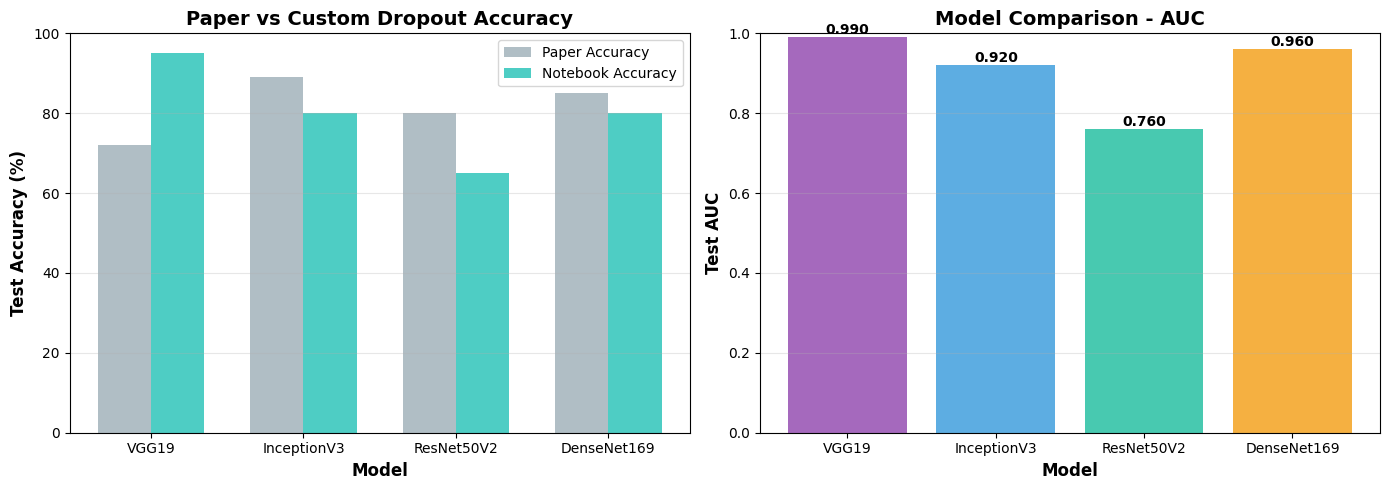

Comparison plot saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/plots/model_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(results.keys())
paper_accs = [results[m]['config']['paper_accuracy'] * 100 for m in model_names]
accuracies = [results[m]['test_acc'] * 100 for m in model_names]
aucs = [results[m]['test_auc'] for m in model_names]
x = np.arange(len(model_names))
width = 0.35

axes[0].bar(x - width / 2, paper_accs, width, label='Paper Accuracy', color='#B0BEC5')
axes[0].bar(x + width / 2, accuracies, width, label='Notebook Accuracy', color='#4ECDC4')
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].set_title('Paper vs Custom Dropout Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].set_ylim([0, 100])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

bars2 = axes[1].bar(model_names, aucs, color=['#A569BD', '#5DADE2', '#48C9B0', '#F5B041'])
axes[1].set_ylabel('Test AUC', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].set_title('Model Comparison - AUC', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1.0])
axes[1].grid(axis='y', alpha=0.3)

for bar, auc in zip(bars2, aucs):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2., height, f'{auc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
comparison_file = os.path.join(PLOT_PATH, 'model_comparison.png')
plt.savefig(comparison_file, dpi=150, bbox_inches='tight')
plt.show()

print('Comparison plot saved:', comparison_file)

---
## STEP 6: SAVE MODELS

In [18]:
print('Saving model metadata to Google Drive...\n')

metadata_rows = []
for model_name, data in results.items():
    metadata_rows.append({
        'model': model_name,
        'final_model_file': data['final_model_file'],
        'checkpoint_file': data['checkpoint_file'],
        'threshold': data['threshold'],
        'test_accuracy': data['test_acc'],
        'test_auc': data['test_auc'],
        'custom_layer': 'Dropout',
        'dropout_rate': DROPOUT_RATE,
    })
    print(f"Model already saved: {data['final_model_file']}")

metadata_df = pd.DataFrame(metadata_rows)
metadata_file = os.path.join(SAVE_PATH, 'model_metadata.csv')
metadata_df.to_csv(metadata_file, index=False)
print(f'Saved: {metadata_file}')

print('\nAll outputs saved to Google Drive!')

Saving model metadata to Google Drive...

Model already saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/VGG19_paper_custom_dropout.keras
Model already saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/InceptionV3_paper_custom_dropout.keras
Model already saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/ResNet50V2_paper_custom_dropout.keras
Model already saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/models/DenseNet169_paper_custom_dropout.keras
Saved: /content/drive/MyDrive/Parkinson_Models_Paper_Custom_Dropout/model_metadata.csv

All outputs saved to Google Drive!


---
## Report Note

Use this explanation in the report:

The notebook keeps the main paper settings: ImageNet pretrained backbones, paper input sizes, paper batch sizes, softmax output, categorical cross-entropy and 50 training epochs. The group's custom contribution is adding one `Dropout` layer after the Dense classification layer. This layer randomly deactivates part of the learned features during training, reducing overfitting risk on the very small 102-image spiral dataset. Accuracy may improve, stay similar or decrease depending on the split, but the design is technically justified because small medical image datasets are prone to overfitting.